# Clasificacion textual supervisada de publicaciones tipo red social

Este notebook desarrolla un baseline clasico de clasificacion supervisada de textos breves en espanol. El objetivo es predecir la categoria tematica de una publicacion tipo red social a partir de su descripcion y sus hashtags mediante una representacion `TF-IDF` y un clasificador `LogisticRegression`.

La narrativa es deliberadamente sencilla: primero se construye un modelo supervisado clasico para clasificar posts. Despues se analizan sus resultados y sus limitaciones semanticas, que motivaran el paso posterior a un recomendador basado en embeddings en el notebook 02.

## 1. Introduccion y objetivo

El problema abordado consiste en asignar automaticamente una etiqueta tematica a cada publicacion a partir de informacion textual. Formalmente, se trata de un problema de clasificacion multiclase supervisada: dado un conjunto de ejemplos etiquetados `(x_i, y_i)`, donde `x_i` representa el texto de una publicacion e `y_i` pertenece a un conjunto finito de categorias, se entrena un modelo capaz de estimar la clase mas probable para textos no vistos durante el entrenamiento.

El enfoque supervisado es adecuado porque el dataset dispone de una variable objetivo explicita, `categoria`, que actua como referencia para aprender la relacion entre patrones lexicos y clases tematicas. Aqui no se busca todavia recomendar contenido por similitud, sino resolver una tarea cerrada de clasificacion y usarla como baseline interpretable y reproducible.

Desde el punto de vista metodologico, este notebook responde a una pregunta concreta: hasta donde puede llegar un enfoque clasico basado en bolsa de palabras cuando las categorias presentan vocabulario distintivo. La respuesta permitira justificar, en el notebook siguiente, por que conviene pasar de clasificacion lexica a recomendacion semantica con embeddings.

In [57]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

DATA_PATH = Path("data/posts.csv")
EXPECTED_COLUMNS = ["id", "descripcion", "hashtags", "categoria"]
TEST_SIZE = 0.30
RANDOM_STATE = 42
TOP_N_TERMS = 10
TOP_N_WORDS = 20

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [58]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")

actual_columns = list(df.columns)
if set(actual_columns) != set(EXPECTED_COLUMNS):
    raise ValueError(
        "El CSV no tiene el esquema esperado. "
        f"Columnas esperadas: {EXPECTED_COLUMNS}. "
        f"Columnas encontradas: {actual_columns}."
    )

df = df[EXPECTED_COLUMNS].copy()

print(f"Archivo cargado correctamente desde: {DATA_PATH}")
print(f"Número total de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
display(df.head())


Archivo cargado correctamente desde: data\posts.csv
Número total de registros: 5000
Número de variables: 4


,id,descripcion,hashtags,categoria
0,1,"temazo, descubriendo joyitas indies en spotify...",#Acustico #Indie,musica
1,2,este gato callejero ya es prácticamente mío qu...,#AmorAnimal #DogLife #Naturaleza #Veterinario,animales
2,3,Literalmente el mejor momento del día: este ga...,NaN,animales
3,4,"Perdidos por Cádiz, perdido en el metro de Rep...",#explorando,viajes
4,5,Próxima parada: pagando un café a precio de tu...,#Paisaje #Naturaleza #Mochileros #RoadTrip #Tr...,viajes


## 2. Análisis exploratorio de datos (EDA)

El análisis exploratorio permite comprobar si el dataset es coherente con el problema que se quiere resolver y detectar posibles limitaciones antes del entrenamiento. En clasificación textual, no basta con revisar el número de registros: también es importante analizar la distribución de clases, la presencia de valores nulos, la longitud de los textos y la señal léxica disponible.

En este caso, cada publicación puede contener dos fuentes textuales: `descripcion` y `hashtags`. La descripción aporta lenguaje natural, mientras que los hashtags tienden a concentrar palabras clave muy informativas. Ambas fuentes se combinarán posteriormente para construir la representación textual del modelo.


In [59]:
print("Valores nulos por columna:")
display(df.isna().sum().to_frame("nulos"))

# La distribución de clases condiciona la lectura de métricas agregadas y el riesgo de sesgo hacia clases mayoritarias.
class_counts = df["categoria"].value_counts().sort_index()
class_distribution = pd.DataFrame(
    {
        "registros": class_counts,
        "porcentaje": (class_counts / len(df) * 100).round(2),
    }
)

print("Distribución de registros por categoría:")
display(class_distribution)


Valores nulos por columna:


,nulos
id,0
descripcion,400
hashtags,750
categoria,0


Distribución de registros por categoría:


,registros,porcentaje
categoria,,
animales,597,11.94
coches,629,12.58
cocina,645,12.90
deporte,594,11.88
musica,624,12.48
playa,654,13.08
viajes,637,12.74
videojuegos,620,12.40


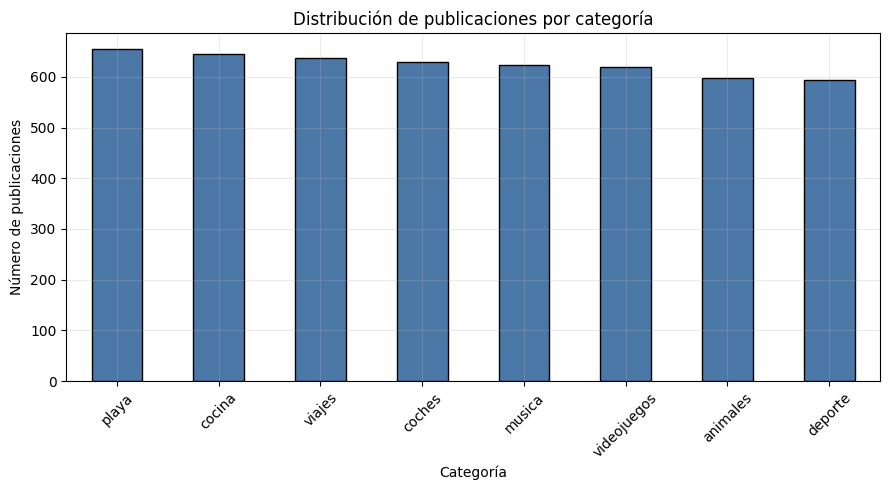

In [60]:
ax = class_counts.sort_values(ascending=False).plot(
    kind="bar",
    color="#4C78A8",
    edgecolor="black",
)
ax.set_title("Distribución de publicaciones por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de publicaciones")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


La distribución por categoría es relevante porque un modelo entrenado con clases muy desbalanceadas puede obtener una exactitud aparentemente alta favoreciendo las categorías mayoritarias. En este dataset las clases presentan tamaños relativamente próximos, aunque no idénticos. Por ello, se utilizará una partición estratificada para conservar proporciones similares entre entrenamiento y prueba.


In [61]:
# Se fusionan descripción y hashtags porque ambos son señales textuales; los hashtags pueden ser muy predictivos y sesgar el modelo hacia palabras clave explícitas.
df["texto_original"] = (
    df["descripcion"].fillna("").astype(str).str.strip()
    + " "
    + df["hashtags"].fillna("").astype(str).str.strip()
).str.strip()

# La longitud aproxima la cantidad de evidencia disponible: textos cortos aumentan la varianza de la predicción y la dependencia de términos aislados.
df["longitud_caracteres"] = df["texto_original"].str.len()
df["longitud_palabras"] = df["texto_original"].apply(lambda text: len(text.split()))

display(
    df[["longitud_caracteres", "longitud_palabras"]]
    .describe()
    .round(2)
)

textos_vacios_originales = (df["texto_original"].str.len() == 0).sum()
print(f"Publicaciones sin descripción ni hashtags: {textos_vacios_originales}")


,longitud_caracteres,longitud_palabras
count,5000.00,5000.00
mean,186.52,27.57
std,1122.25,160.28
min,0.00,0.00
25%,65.00,11.00
50%,83.00,13.00
75%,99.00,15.00
max,14153.00,2005.00


Publicaciones sin descripción ni hashtags: 69


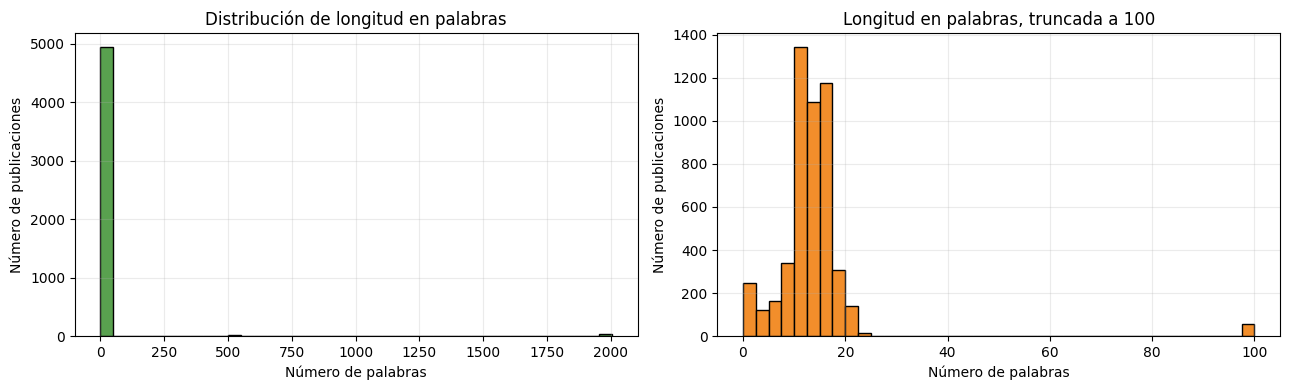

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["longitud_palabras"].plot(
    kind="hist",
    bins=40,
    color="#59A14F",
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_title("Distribución de longitud en palabras")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Número de publicaciones")

# El recorte solo afecta a la visualización; evita que valores extremos oculten la distribución principal de longitudes.
df["longitud_palabras"].clip(upper=100).plot(
    kind="hist",
    bins=40,
    color="#F28E2B",
    edgecolor="black",
    ax=axes[1],
)
axes[1].set_title("Longitud en palabras, truncada a 100")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Número de publicaciones")

plt.tight_layout()
plt.show()


La longitud de las publicaciones condiciona la dificultad del problema. Los textos breves contienen menos contexto, por lo que el modelo depende más de palabras clave y hashtags. Además, la presencia de textos extremadamente largos puede introducir ruido si su vocabulario no está alineado con la categoría real. Esta heterogeneidad es una limitación habitual en datos tipo red social.


In [63]:
def preprocesar_texto(texto: str) -> str:
    """Normaliza texto para un modelo clásico basado en bolsa de palabras."""
    # La normalización reduce la dimensionalidad léxica; también puede eliminar señales útiles como puntuación, emojis o marcas de estilo.
    texto = str(texto).lower()
    texto = texto.replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# El modelo posterior no aprende semántica contextual, sino asociaciones entre tokens normalizados y categorías.
df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
df["longitud_limpia_palabras"] = df["texto_limpio"].apply(lambda text: len(text.split()))

textos_vacios_limpios = (df["texto_limpio"].str.len() == 0).sum()
print(f"Publicaciones sin señal textual tras el preprocesamiento: {textos_vacios_limpios}")

display(df[["descripcion", "hashtags", "texto_original", "texto_limpio"]].head(8))


Publicaciones sin señal textual tras el preprocesamiento: 69


,descripcion,hashtags,texto_original,texto_limpio
0,"temazo, descubriendo joyitas indies en spotify...",#Acustico #Indie,"temazo, descubriendo joyitas indies en spotify...",temazo descubriendo joyitas indies en spotify ...
1,este gato callejero ya es prácticamente mío qu...,#AmorAnimal #DogLife #Naturaleza #Veterinario,este gato callejero ya es prácticamente mío qu...,este gato callejero ya es prácticamente mío qu...
2,Literalmente el mejor momento del día: este ga...,NaN,Literalmente el mejor momento del día: este ga...,literalmente el mejor momento del día este gat...
3,"Perdidos por Cádiz, perdido en el metro de Rep...",#explorando,"Perdidos por Cádiz, perdido en el metro de Rep...",perdidos por cádiz perdido en el metro de repú...
4,Próxima parada: pagando un café a precio de tu...,#Paisaje #Naturaleza #Mochileros #RoadTrip #Tr...,Próxima parada: pagando un café a precio de tu...,próxima parada pagando un café a precio de tur...
5,"Que ternura, mi perro corriendo como un loco p...",#mascotas#animallover#michis,"Que ternura, mi perro corriendo como un loco p...",que ternura mi perro corriendo como un loco po...
6,"brum brum, la gasolina a precio de oooooro per...",#carporn #tuning #llantas #exhaust #v8,"brum brum, la gasolina a precio de oooooro per...",brum brum la gasolina a precio de oooooro pero...
7,"perdido en el metro de Sierra Leona, ayuda me ...",#roadtrip#paisaje#escapada,"perdido en el metro de Sierra Leona, ayuda me ...",perdido en el metro de sierra leona ayuda me m...


,palabra,frecuencia
0,siempre,645
1,buenos,578
2,marco,575
3,desarrollo,575
4,año,574
5,investigación,570
6,resultados,568
7,dicho,567
8,condiciones,566
9,cuarto,565


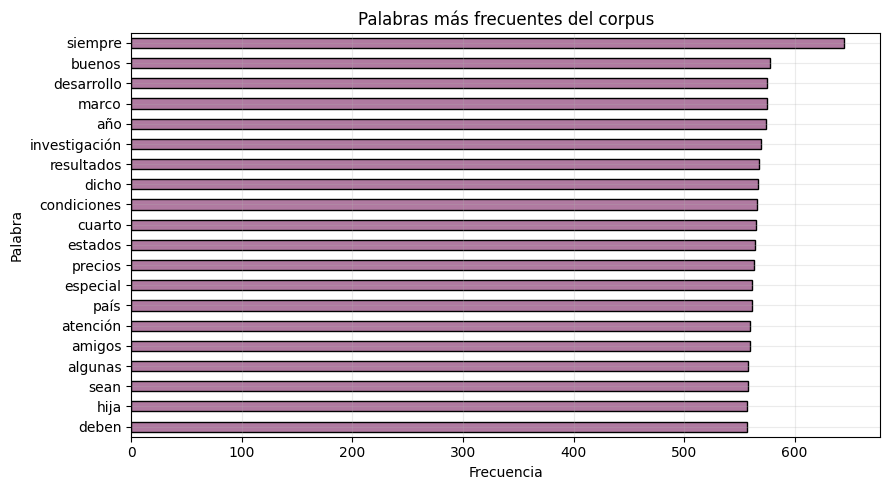

In [64]:
SPANISH_STOPWORDS = {
    "a", "al", "algo", "ante", "antes", "como", "con", "contra", "cual", "cuando",
    "de", "del", "desde", "donde", "durante", "e", "el", "ella", "ellas", "ellos",
    "en", "entre", "era", "eran", "es", "esa", "esas", "ese", "eso", "esos", "esta",
    "estaba", "estaban", "estado", "estan", "estar", "estas", "este", "esto", "estos",
    "fue", "ha", "hay", "he", "la", "las", "le", "les", "lo", "los", "mas", "me",
    "mi", "mis", "mucho", "muy", "ni", "no", "nos", "o", "para", "pero", "por",
    "que", "se", "sin", "sobre", "su", "sus", "tambien", "tan", "te", "tiene",
    "todo", "tras", "tu", "un", "una", "unas", "uno", "unos", "y", "ya"
}

# Este análisis explora el vocabulario global, pero no se utiliza para ajustar el modelo y por tanto no introduce fuga de información.
tokens = []
for texto in df["texto_limpio"]:
    tokens.extend(
        token for token in texto.split()
        if token not in SPANISH_STOPWORDS and len(token) > 2
    )

frecuencias_globales = pd.DataFrame(
    Counter(tokens).most_common(TOP_N_WORDS),
    columns=["palabra", "frecuencia"],
)

display(frecuencias_globales)

ax = frecuencias_globales.sort_values("frecuencia").plot(
    kind="barh",
    x="palabra",
    y="frecuencia",
    legend=False,
    color="#B07AA1",
    edgecolor="black",
)
ax.set_title("Palabras más frecuentes del corpus")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Palabra")
plt.tight_layout()
plt.show()


El análisis de palabras frecuentes ayuda a comprobar si existen términos temáticamente informativos y si el corpus contiene ruido. En un dataset de publicaciones sociales es esperable encontrar vocabulario muy específico, como términos asociados a deporte, cocina, viajes o videojuegos, junto con palabras más generales. Esta observación justifica el uso de TF-IDF, ya que esta técnica reduce el peso relativo de términos frecuentes en muchos documentos y destaca palabras más características de cada publicación.

Como limitación, el EDA también muestra que existen registros sin señal textual tras combinar descripción y hashtags. Estos casos no aportan información para un clasificador textual y, si se mantienen en entrenamiento, obligan al modelo a aprender a partir de vectores vacíos o poco informativos. Por ello, se conservarán en el análisis descriptivo del dataset, pero se excluirán de la fase de modelado.


## 3. Metodología

La metodología sigue un flujo clásico de aprendizaje supervisado para texto: preparación de la variable de entrada, eliminación de registros sin información textual, separación en entrenamiento y prueba, vectorización TF-IDF y entrenamiento de un clasificador lineal.

La separación entre entrenamiento y prueba se realiza antes de ajustar el vectorizador. Esta decisión evita fuga de información, ya que el vocabulario y las ponderaciones IDF deben aprenderse únicamente con los datos de entrenamiento. El conjunto de prueba debe simular datos no vistos para estimar de forma honesta la capacidad de generalización del modelo.


In [65]:
# Se excluyen textos sin señal observable; esto mejora el entrenamiento, pero puede sobreestimar el rendimiento si en producción aparecen entradas vacías.
df_modelo = df[df["texto_limpio"].str.len() > 0].copy()

print(f"Registros originales: {len(df)}")
print(f"Registros utilizados para modelado: {len(df_modelo)}")
print(f"Registros excluidos por texto vacío: {len(df) - len(df_modelo)}")
print(f"Textos vacíos en df_modelo: {(df_modelo['texto_limpio'].str.len() == 0).sum()}")

X = df_modelo["texto_limpio"]
y = df_modelo["categoria"]


Registros originales: 5000
Registros utilizados para modelado: 4931
Registros excluidos por texto vacío: 69
Textos vacíos en df_modelo: 0


In [66]:
# La partición separa ajuste y evaluación; el test actúa como aproximación a datos no vistos.
# stratify conserva la proporción de clases y random_state fija la muestra para hacer reproducible la comparación experimental.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    }
)
split_distribution["train_%"] = (split_distribution["train"] / len(y_train) * 100).round(2)
split_distribution["test_%"] = (split_distribution["test"] / len(y_test) * 100).round(2)

display(split_distribution)


,train,test,train_%,test_%
categoria,,,,
animales,409,176,11.85,11.89
coches,435,187,12.61,12.64
cocina,449,192,13.01,12.97
deporte,411,176,11.91,11.89
musica,430,184,12.46,12.43
playa,451,193,13.07,13.04
viajes,438,188,12.69,12.70
videojuegos,428,184,12.40,12.43


El parámetro `stratify=y` mantiene en entrenamiento y prueba proporciones similares de cada categoría. Esto es importante porque, incluso con clases relativamente equilibradas, una partición aleatoria simple podría dejar alguna clase infrarepresentada en el conjunto de prueba y distorsionar la evaluación.

El valor `random_state=42` fija la semilla aleatoria. Su función no es mejorar el modelo, sino garantizar reproducibilidad: cualquier persona que ejecute el notebook con los mismos datos obtendrá la misma partición y podrá comparar resultados de forma consistente.


In [67]:
# TF-IDF pondera frecuencia local e inversa documental: frente a conteos simples, penaliza términos comunes y resalta vocabulario discriminativo.
vectorizer = TfidfVectorizer()
# fit_transform aprende vocabulario e IDF solo en train; hacerlo sobre todo el corpus filtraría información del test.
X_train_tfidf = vectorizer.fit_transform(X_train)
# En test se reutilizan vocabulario e IDF aprendidos; términos nuevos no influyen en la predicción.
X_test_tfidf = vectorizer.transform(X_test)

print(f"Documentos de entrenamiento: {X_train_tfidf.shape[0]}")
print(f"Documentos de prueba: {X_test_tfidf.shape[0]}")
print(f"Tamaño del vocabulario aprendido: {X_train_tfidf.shape[1]}")


Documentos de entrenamiento: 3451
Documentos de prueba: 1480
Tamaño del vocabulario aprendido: 1860


TF-IDF transforma cada texto en un vector numérico. La frecuencia de término mide cuántas veces aparece una palabra en un documento, mientras que el componente IDF reduce la importancia de palabras que aparecen en muchos documentos y, por tanto, tienen menor capacidad discriminativa.

Esta representación es adecuada como baseline en clasificación textual porque es eficiente, interpretable y suele ofrecer buenos resultados cuando las categorías están asociadas a vocabularios diferenciados. Además, no requiere modelos preentrenados ni grandes volúmenes de datos, lo cual resulta coherente con una primera aproximación experimental dentro del TFM.


In [68]:
# El clasificador lineal aprende pesos por término para separar clases en el espacio TF-IDF, no significados lingüísticos profundos.
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
# fit optimiza los coeficientes minimizando una pérdida logística regularizada sobre los ejemplos etiquetados de entrenamiento.
model.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente.")
print(f"Clases aprendidas: {list(model.classes_)}")


Modelo entrenado correctamente.
Clases aprendidas: ['animales', 'coches', 'cocina', 'deporte', 'musica', 'playa', 'viajes', 'videojuegos']


Logistic Regression es un clasificador lineal que estima, para cada clase, una combinación ponderada de las características de entrada. En este caso, las características son términos ponderados mediante TF-IDF. Aunque su nombre incluya la palabra “regression”, en este contexto se utiliza para clasificación multiclase.

Una ventaja de este modelo es su interpretabilidad: los coeficientes asociados a cada término indican cuánto contribuye ese término a aumentar la puntuación de una clase frente a las demás. Por ejemplo, si una palabra tiene un coeficiente alto y positivo para `cocina`, su presencia ponderada en un texto empuja la predicción hacia esa categoría. Esta propiedad permite no solo evaluar el rendimiento, sino también inspeccionar qué señales lingüísticas está utilizando el modelo.


In [69]:
# Los coeficientes conectan cada término TF-IDF con el logit de una clase; valores positivos altos aumentan su evidencia relativa.
feature_names = vectorizer.get_feature_names_out()
top_terms_rows = []

for class_index, categoria in enumerate(model.classes_):
    # Los términos superiores muestran señales aprendidas, aunque pueden capturar artefactos del dataset y no causalidad temática.
    top_indices = model.coef_[class_index].argsort()[-TOP_N_TERMS:][::-1]
    for posicion, term_index in enumerate(top_indices, start=1):
        top_terms_rows.append(
            {
                "categoria": categoria,
                "posicion": posicion,
                "termino": feature_names[term_index],
                "coeficiente": round(float(model.coef_[class_index][term_index]), 4),
            }
        )

top_terms_df = pd.DataFrame(top_terms_rows)
display(top_terms_df)


,categoria,posicion,termino,coeficiente
0,animales,1,paseo,3.0130
1,animales,2,cachorro,2.1383
2,animales,3,veterinario,2.0732
3,animales,4,animales,1.9835
4,animales,5,cute,1.8766
...,...,...,...,...
75,videojuegos,6,twitch,1.7277
76,videojuegos,7,retrogaming,1.7236
77,videojuegos,8,playstation,1.7108
78,videojuegos,9,toda,1.7021


## 4. Evaluación

La evaluación se realiza exclusivamente sobre el conjunto de prueba. Este conjunto no ha participado ni en el aprendizaje del vocabulario TF-IDF ni en el ajuste de los coeficientes de Logistic Regression. Por tanto, sus resultados ofrecen una estimación más realista del comportamiento esperado ante publicaciones no vistas.

Se utilizan métricas globales y por clase. En problemas multiclase, las métricas macro son especialmente útiles porque calculan primero el resultado de cada clase y después promedian, asignando el mismo peso a todas las categorías independientemente de su tamaño.


In [70]:
# Las predicciones se generan únicamente con representaciones del test transformadas con parámetros aprendidos en train.
y_pred = model.predict(X_test_tfidf)

# Accuracy mide acierto global; puede ser optimista si una clase domina o si los errores minoritarios quedan ocultos.
accuracy = accuracy_score(y_test, y_pred)
# Precision_macro penaliza falsos positivos por clase dando el mismo peso a todas las categorías.
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
# Recall_macro mide la capacidad de recuperar cada clase real; es sensible a clases que el modelo ignora.
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
# F1_macro resume precision y recall por clase; puede ocultar qué categoría concreta falla si no se revisa el informe detallado.
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

metricas_globales = pd.DataFrame(
    {
        "métrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [accuracy, precision_macro, recall_macro, f1_macro],
    }
)
metricas_globales["valor"] = metricas_globales["valor"].round(4)

display(metricas_globales)

print("Classification report:")
# El informe por clase permite detectar sesgos que las métricas globales pueden promediar en exceso.
print(classification_report(y_test, y_pred, zero_division=0))


,métrica,valor
0,accuracy,0.9851
1,precision_macro,0.9854
2,recall_macro,0.9853
3,f1_macro,0.9853


Classification report:
              precision    recall  f1-score   support

    animales       1.00      1.00      1.00       176
      coches       1.00      0.98      0.99       187
      cocina       0.96      0.96      0.96       192
     deporte       0.96      0.98      0.97       176
      musica       1.00      1.00      1.00       184
       playa       0.97      0.99      0.98       193
      viajes       0.99      0.99      0.99       188
 videojuegos       1.00      0.98      0.99       184

    accuracy                           0.99      1480
   macro avg       0.99      0.99      0.99      1480
weighted avg       0.99      0.99      0.99      1480



La `accuracy` representa la proporción total de predicciones correctas. La `precision` indica, para una clase, qué proporción de las predicciones realizadas como esa clase eran realmente correctas. El `recall` mide qué proporción de los casos reales de una clase fueron recuperados por el modelo. El `F1-score` combina precision y recall mediante su media armónica, por lo que resulta útil cuando se busca un equilibrio entre falsos positivos y falsos negativos.

El promedio macro evita que las clases con más ejemplos dominen la lectura agregada. En este proyecto es una elección apropiada porque todas las categorías tienen relevancia conceptual dentro del sistema de clasificación, no solo las más frecuentes.


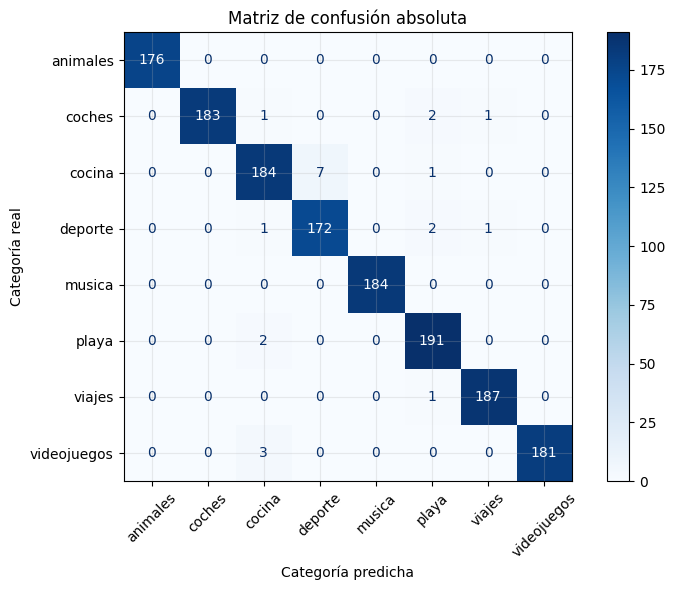

In [71]:
# Se fija el orden de etiquetas para que filas y columnas de las matrices sean comparables entre ejecuciones.
labels = list(model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
# Filas = clase real, columnas = clase predicha; la diagonal son aciertos y la zona externa son confusiones específicas.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=True,
)
ax.set_title("Matriz de confusión absoluta")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()


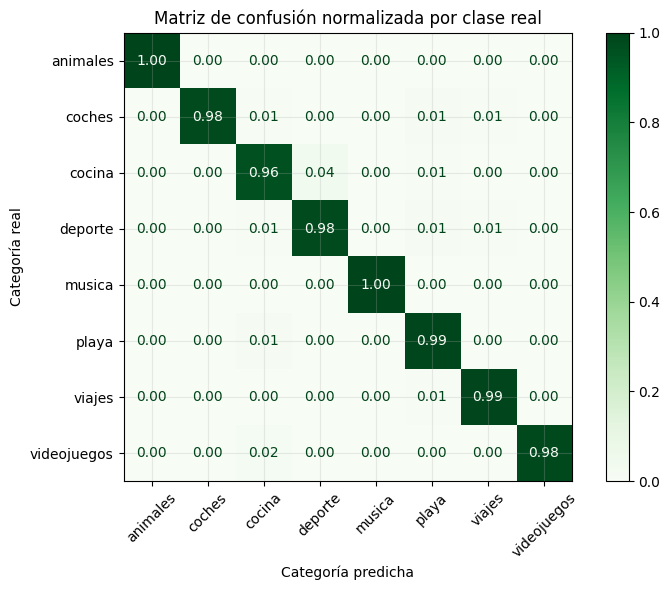

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
# normalize="true" convierte cada fila en proporciones: interpreta los errores condicionados a cada clase real.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=labels,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    xticks_rotation=45,
    ax=ax,
    colorbar=True,
)
ax.set_title("Matriz de confusión normalizada por clase real")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()


La matriz de confusión debe leerse con filas como clases reales y columnas como clases predichas. Los valores de la diagonal principal son aciertos. Los valores fuera de la diagonal representan errores: por ejemplo, una celda en la fila `cocina` y la columna `deporte` indica publicaciones reales de cocina clasificadas como deporte.

La matriz absoluta muestra el número de casos, mientras que la matriz normalizada por clase real expresa proporciones dentro de cada fila. Esta segunda versión facilita comparar clases con distinto número de ejemplos, ya que cada fila se interpreta como distribución porcentual de las predicciones realizadas para una clase real.


## 5. Analisis de resultados y limitaciones del enfoque TF-IDF

Ademas de presentar metricas, es necesario interpretar que esta funcionando, donde se producen errores y por que. En modelos basados en bolsa de palabras, los aciertos suelen depender de la existencia de terminos muy caracteristicos de cada categoria. Los errores aparecen cuando el texto es corto, ambiguo, contiene vocabulario compartido entre clases o incluye ruido no relacionado con la etiqueta.

Este punto es importante para la historia del TFM: el baseline clasico funciona bien cuando las clases estan separadas por palabras clave, pero su capacidad semantica es limitada. Por eso, tras documentar su rendimiento, el siguiente paso natural sera sustituir esta representacion por embeddings densos en el notebook 02.

In [73]:
# El support contextualiza la estabilidad de cada métrica: con pocos ejemplos, precision y recall fluctúan más.
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[labels, ["precision", "recall", "f1-score", "support"]].copy()
class_report_df[["precision", "recall", "f1-score"]] = class_report_df[
    ["precision", "recall", "f1-score"]
].round(4)
class_report_df["support"] = class_report_df["support"].astype(int)

display(class_report_df.sort_values("f1-score", ascending=False))

best_classes = class_report_df.sort_values("f1-score", ascending=False).head(3)
print("Clases con mayor F1-score:")
for categoria, row in best_classes.iterrows():
    print(f"- {categoria}: F1={row['f1-score']:.4f}, precision={row['precision']:.4f}, recall={row['recall']:.4f}")


,precision,recall,f1-score,support
animales,1.0000,1.0000,1.0000,176
musica,1.0000,1.0000,1.0000,184
viajes,0.9894,0.9947,0.9920,188
videojuegos,1.0000,0.9837,0.9918,184
coches,1.0000,0.9786,0.9892,187
playa,0.9695,0.9896,0.9795,193
deporte,0.9609,0.9773,0.9690,176
cocina,0.9634,0.9583,0.9608,192


Clases con mayor F1-score:
- animales: F1=1.0000, precision=1.0000, recall=1.0000
- musica: F1=1.0000, precision=1.0000, recall=1.0000
- viajes: F1=0.9920, precision=0.9894, recall=0.9947


In [74]:
# Extraer solo la diagonal externa ayuda a identificar patrones sistemáticos de solapamiento léxico entre categorías.
cm = confusion_matrix(y_test, y_pred, labels=labels)
confusion_rows = []

for real_index, real_label in enumerate(labels):
    for pred_index, pred_label in enumerate(labels):
        if real_index != pred_index and cm[real_index, pred_index] > 0:
            confusion_rows.append(
                {
                    "categoria_real": real_label,
                    "categoria_predicha": pred_label,
                    "casos": int(cm[real_index, pred_index]),
                }
            )

confusiones_df = pd.DataFrame(confusion_rows).sort_values("casos", ascending=False)
display(confusiones_df)


,categoria_real,categoria_predicha,casos
3,cocina,deporte,7
10,videojuegos,cocina,3
1,coches,playa,2
8,playa,cocina,2
6,deporte,playa,2
2,coches,viajes,1
0,coches,cocina,1
5,deporte,cocina,1
4,cocina,playa,1
7,deporte,viajes,1


## 6. Conclusiones

El baseline `TF-IDF + LogisticRegression` ofrece un rendimiento alto en este dataset porque muchas categorias contienen vocabulario tematico muy reconocible. La combinacion entre una representacion dispersa y un clasificador lineal resulta especialmente eficaz cuando existen palabras o hashtags con fuerte capacidad discriminativa.

Sin embargo, este enfoque presenta limitaciones claras. TF-IDF no modela el significado contextual, no representa sinonimos de forma natural y depende de que las palabras relevantes hayan aparecido en el vocabulario aprendido durante entrenamiento. Dos publicaciones semanticamente parecidas pueden quedar lejos si no comparten terminos, mientras que textos con palabras parecidas pueden quedar cerca aunque su significado global difiera.

En consecuencia, este notebook cumple el papel de baseline supervisado clasico: muestra que la clasificacion funciona bien, pero tambien que su exito depende en gran medida de la separacion lexica entre categorias. Esa limitacion semantica motiva el paso al notebook 02, donde se abandona la clasificacion cerrada y se construye un sistema de recomendacion semantica basado en embeddings.